### Получаем данные

In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="local",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89130.601562,89139.500000,89130.500000,89135.101562,0.769,0.000,0.000,0.000,0.000000,...,0.014,1.000,0.139,0.002,0.005,0.141,1.796,0.821,0.006,0.139
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.000,0.196,-1.000000,...,0.139,0.002,0.139,0.744,0.139,1.010,1.796,0.139,0.112,1.139
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.000,0.000,0.000000,...,0.020,0.023,0.139,1.094,0.139,1.075,1.796,0.139,1.008,1.139
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.000,0.000,0.000000,...,0.002,0.139,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.000,0.004,-1.000000,...,0.005,0.139,0.415,0.003,0.139,0.004,0.139,0.978,0.139,0.744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676189,2026-03-03 14:59:35,66521.898438,66533.898438,66511.898438,66532.101562,1.900,0.190,0.002,0.188,-0.978947,...,0.002,0.005,0.002,0.349,0.013,0.002,0.038,0.363,0.020,0.006
676190,2026-03-03 14:59:40,66523.898438,66533.898438,66518.398438,66532.500000,2.163,0.217,0.217,0.000,1.000000,...,0.038,0.007,0.141,0.004,0.349,0.218,0.041,0.903,0.011,0.004
676191,2026-03-03 14:59:45,66525.703125,66528.796875,66518.500000,66520.000000,1.556,0.150,0.015,0.135,-0.800000,...,0.025,0.020,0.181,0.301,0.905,0.012,0.002,0.362,0.218,0.023
676192,2026-03-03 14:59:50,66529.000000,66529.703125,66518.500000,66526.203125,2.696,0.085,0.049,0.036,0.152941,...,0.002,0.314,0.002,0.370,0.002,0.002,0.007,0.348,0.030,0.020


### Определяем таргеты для всех моделей

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 676193/676193 [00:05<00:00, 113499.84it/s]


### Генерируем фичи для всех моделей

In [3]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,1.591322e-04,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.137518,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,2.141049e-04,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.130633,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,2.752305e-04,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.130633,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,4.429674e-04,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.127256,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,9.560574e-04,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.134238,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676189,20.043750,1.575859,43.764249,38.649818,1.416966e-11,20.043720,0.048516,-3.777724,-1.633820,-54.205601,...,1.013785,0.196180,-4.878558,-0.869876,-0.880058,66511.898438,66533.898438,66532.101562,-0.000089,0.000233
676190,18.590365,0.057281,42.822107,37.329124,1.618058e-11,18.590336,1.400000,0.057681,0.025977,5.059241,...,0.982902,1.307547,0.549401,0.105753,0.103492,66518.398438,66533.898438,66532.500000,-0.000133,0.000155
676191,18.340365,0.221805,41.861370,35.750760,7.968021e-11,18.340337,0.006000,-2.718254,-1.582602,-38.547141,...,0.997242,0.713886,-4.326840,-0.892355,-0.973788,66518.500000,66528.796875,66520.000000,0.000062,0.000168
676192,17.520312,0.020516,40.839429,34.054913,3.024983e-10,17.520286,0.278906,0.316944,0.115096,11.647667,...,0.941413,0.708732,1.010408,0.276918,0.250563,66518.500000,66529.703125,66526.203125,-0.000066,0.000337


In [4]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [5]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=3,
)

Обучение модели...
[0]	validation_0-rmse:0.00023
[50]	validation_0-rmse:0.00022
[100]	validation_0-rmse:0.00021
[150]	validation_0-rmse:0.00021
[200]	validation_0-rmse:0.00021
[250]	validation_0-rmse:0.00021
[300]	validation_0-rmse:0.00020
[350]	validation_0-rmse:0.00020
[400]	validation_0-rmse:0.00020
[450]	validation_0-rmse:0.00020
[500]	validation_0-rmse:0.00020
[550]	validation_0-rmse:0.00020
[600]	validation_0-rmse:0.00020
[650]	validation_0-rmse:0.00020
[700]	validation_0-rmse:0.00020
[750]	validation_0-rmse:0.00020
[800]	validation_0-rmse:0.00020
[850]	validation_0-rmse:0.00020
[900]	validation_0-rmse:0.00020
[950]	validation_0-rmse:0.00020
[1000]	validation_0-rmse:0.00020
[1050]	validation_0-rmse:0.00020
[1100]	validation_0-rmse:0.00020
[1150]	validation_0-rmse:0.00020
[1200]	validation_0-rmse:0.00020
[1250]	validation_0-rmse:0.00020
[1298]	validation_0-rmse:0.00020
Модель сохранена в директорию: models/model_mid.json


MAE                      : 0.000128
RMSE                     : 0.000202
R²                       : 0.207705
MAE / mean|Δ|            : 0.857660
RMSE / RMSE_base         : 0.890102
mean|Δ| (target)         : 0.000149

------------------------------------------------------------
Directional Accuracy     : 0.638187
Target Pos Ratio         : 0.491078
Profit Factor            : -0.370259
Avg Gain (correct)       : -0.000000
Avg Loss (incorrect)     : -0.000002

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6357, 0.6406)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000118, 0.00128]    0.000212         0.904984    -0.000001      13524
(6.78e-05, 0.000118]    0.000089         0.791466    -0.000002      13523
(4.72e-05, 6.78e-05]    0.000056         0.710419     0.000002      13523

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


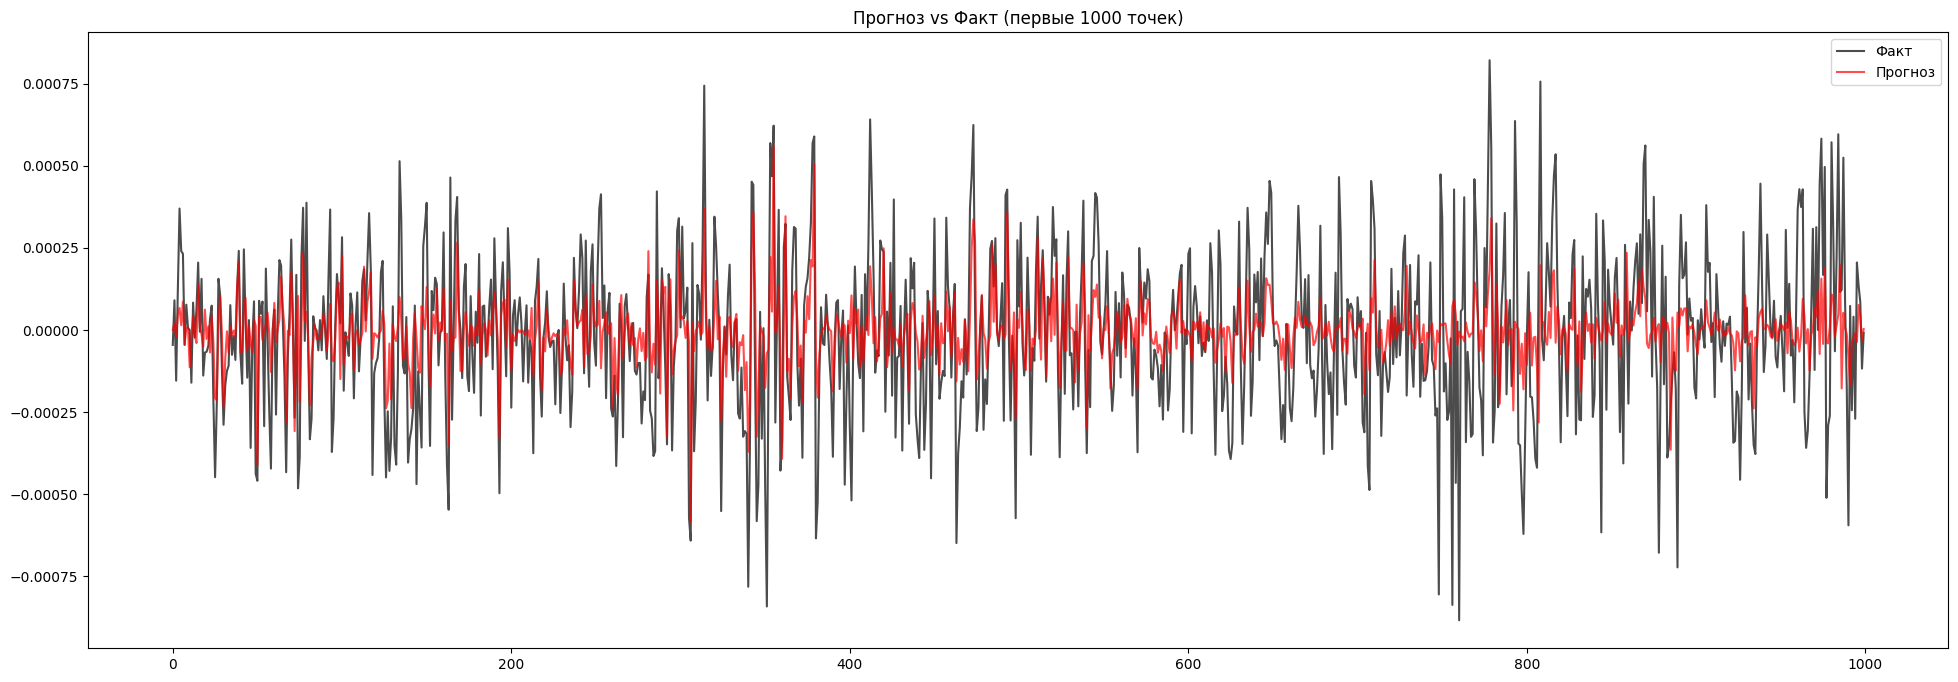

In [6]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [7]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=6,
)

Обучение модели...
[0]	validation_0-rmse:0.00024
[50]	validation_0-rmse:0.00021
[100]	validation_0-rmse:0.00019
[150]	validation_0-rmse:0.00019
[200]	validation_0-rmse:0.00019
[250]	validation_0-rmse:0.00019
[300]	validation_0-rmse:0.00019
[350]	validation_0-rmse:0.00019
[400]	validation_0-rmse:0.00019
[415]	validation_0-rmse:0.00019
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000122
RMSE                     : 0.000187
R²                       : 0.395894
MAE / mean|Δ|            : 0.533594
RMSE / RMSE_base         : 0.564320
mean|Δ| (target)         : 0.000228

------------------------------------------------------------
Directional Accuracy     : 0.942078
Target Pos Ratio         : 0.942078
Profit Factor            : 30855662002.651394
Avg Gain (correct)       : 0.000242
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.9407, 0.9433)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000407, 0.00266]    0.000583         1.000000     0.000576      13524
(0.000305, 0.000407]    0.000350         0.998077     0.000341      13523
 (0.00025, 0.000305]    0.000276         0.994306     0.000273    

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


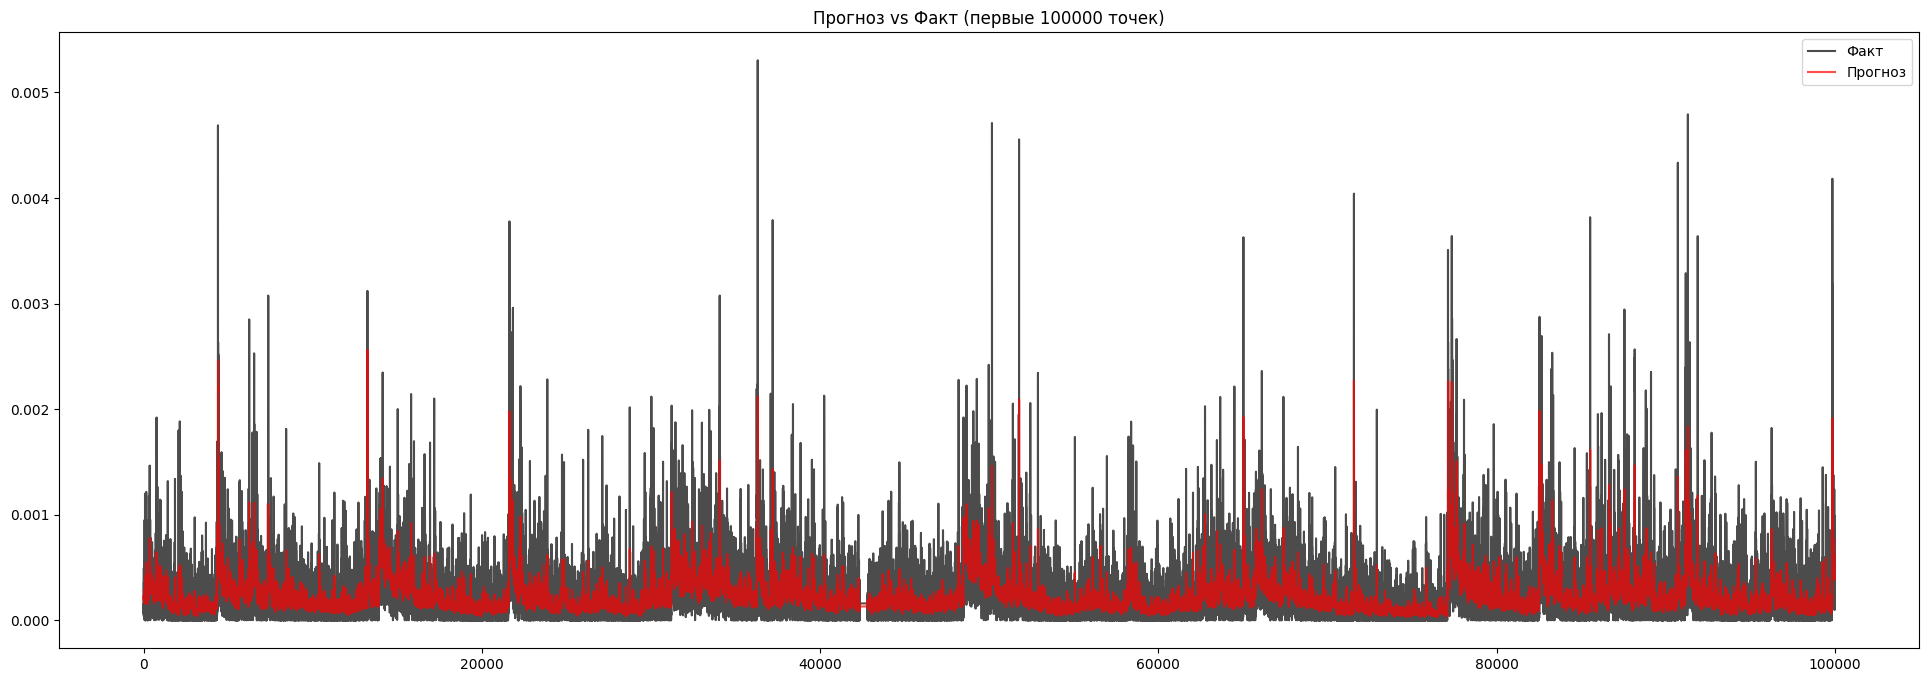

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)